# QAOA Depth Sweep: Penalty vs XY Mixer

Comparing **Expected Approximation Ratios** and **Feasibility Probabilities** across QAOA depths P=1,2,3,4,5 for three models:
1. **Tight Penalty** QUBO (λ from relaxation gap)
2. **Naive Penalty** QUBO (λ = 10³)
3. **XY Mixer** QAOA (ring topology, Dicke initial state)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from pde_qaoa_helpers import (
    load_pde_data, generate_pde_qubo, compute_lambda,
    build_penalty_qubo, build_bqo, solve_classically,
    prepare_dicke_state, build_ring_xy_mixer,
    run_depth_sweep, estimate_resources,
    plot_depth_sweep,
)

## Problem Setup

In [2]:
Phi, M, Kinv, yhat_vec = load_pde_data('ifiss3.6/QUBO_3.mat')
s = 2

Q, q, c = generate_pde_qubo(M, Kinv, Phi, yhat_vec)
n_original = q.shape[0]
print(f'Q: {Q.shape}, q: {q.shape}, c: {float(c):.6f}')
print(f'Number of original decision variables: {n_original}')
print(f'condition number: {np.linalg.cond(Q)}')

Q: (12, 12), q: (12,), c: 0.474948
Number of original decision variables: 12
condition number: 7308842317.319669


## Build Models

In [3]:
lam_tight = compute_lambda(Q, q, c, s)
lam_naive = 1e3

qubo_tight = build_penalty_qubo(Q, q, c, s, lam_tight, "Tight Penalty QUBO")
qubo_naive = build_penalty_qubo(Q, q, c, s, lam_naive, "Naive Penalty QUBO")
bqo = build_bqo(Q, q, c, s, constraint_sense="<=")
prob_size = n_original + s

print(f"Tight penalty lambda: {lam_tight:.4f}")
print(f"Naive penalty lambda: {lam_naive:.2e}")
print(f"Tight QUBO: {qubo_tight.get_num_vars()} vars")
print(f"Naive QUBO: {qubo_naive.get_num_vars()} vars")
print(f"BQO: {bqo.get_num_vars()} vars ({prob_size} qubits)")

Tight penalty lambda: 24.2087
Naive penalty lambda: 1.00e+03
Tight QUBO: 14 vars
Naive QUBO: 14 vars
BQO: 14 vars (14 qubits)


In [4]:
classical_result = solve_classically(bqo)
optimal_value = classical_result.fval
print(f"Optimal value: {optimal_value:.6f}")
print(f"Optimal solution: {[int(x) for x in classical_result.x]}")
print(f"Hamming weight: {int(sum(classical_result.x))}")

# Remove constraint for XY mixer (enforced by mixer + initial state)
try:
    bqo.remove_linear_constraint("hamming_weight")
except:
    pass

init_qc = prepare_dicke_state(prob_size, s)
ring_xy_mixer = build_ring_xy_mixer(prob_size)
print(f"\nXY Mixer setup: {prob_size} qubits, Dicke |D({prob_size},{s})>")

Optimal value: 0.474948
Optimal solution: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Hamming weight: 0

XY Mixer setup: 14 qubits, Dicke |D(14,2)>


## Depth Sweeps

In [5]:
depths = [1, 2, 3, 4, 5]

print("=" * 60)
print(f"Model 1: Tight Penalty (lambda = {lam_tight:.4f})")
print("=" * 60)
ar_tight, feas_tight = run_depth_sweep(
    qubo_tight, depths, optimal_value, n_original, s,
    model_name="Tight Penalty"
)

Model 1: Tight Penalty (lambda = 24.2087)
  [Tight Penalty] P=1: E[AR]=0.0295, Feas=0.0249 (31.9s)
  [Tight Penalty] P=2: E[AR]=0.0159, Feas=0.0268 (38.2s)
  [Tight Penalty] P=3: E[AR]=0.0937, Feas=0.1272 (40.5s)
  [Tight Penalty] P=4: E[AR]=0.0110, Feas=0.0274 (44.7s)
  [Tight Penalty] P=5: E[AR]=0.0197, Feas=0.0172 (48.1s)


In [6]:
print("=" * 60)
print(f"Model 2: Naive Penalty (lambda = {lam_naive:.2e})")
print("=" * 60)
ar_naive, feas_naive = run_depth_sweep(
    qubo_naive, depths, optimal_value, n_original, s,
    model_name="Naive Penalty"
)

Model 2: Naive Penalty (lambda = 1.00e+03)
  [Naive Penalty] P=1: E[AR]=0.0115, Feas=0.0357 (33.9s)
  [Naive Penalty] P=2: E[AR]=0.0069, Feas=0.0221 (37.3s)
  [Naive Penalty] P=3: E[AR]=0.0268, Feas=0.0262 (43.5s)
  [Naive Penalty] P=4: E[AR]=0.0088, Feas=0.0274 (41.1s)
  [Naive Penalty] P=5: E[AR]=0.0360, Feas=0.0245 (45.7s)


In [7]:
print("=" * 60)
print("Model 3: XY Mixer (Ring)")
print("=" * 60)
ar_xy, feas_xy = run_depth_sweep(
    bqo, depths, optimal_value, n_original, s,
    model_name="XY Mixer",
    initial_state=init_qc,
    mixer=ring_xy_mixer,
)

Model 3: XY Mixer (Ring)
  [XY Mixer] P=1: E[AR]=0.0552, Feas=1.0000 (12.0s)
  [XY Mixer] P=2: E[AR]=0.0771, Feas=1.0000 (16.1s)
  [XY Mixer] P=3: E[AR]=0.0552, Feas=1.0000 (20.0s)
  [XY Mixer] P=4: E[AR]=0.0567, Feas=1.0000 (24.4s)
  [XY Mixer] P=5: E[AR]=0.0483, Feas=1.0000 (28.2s)


## Results

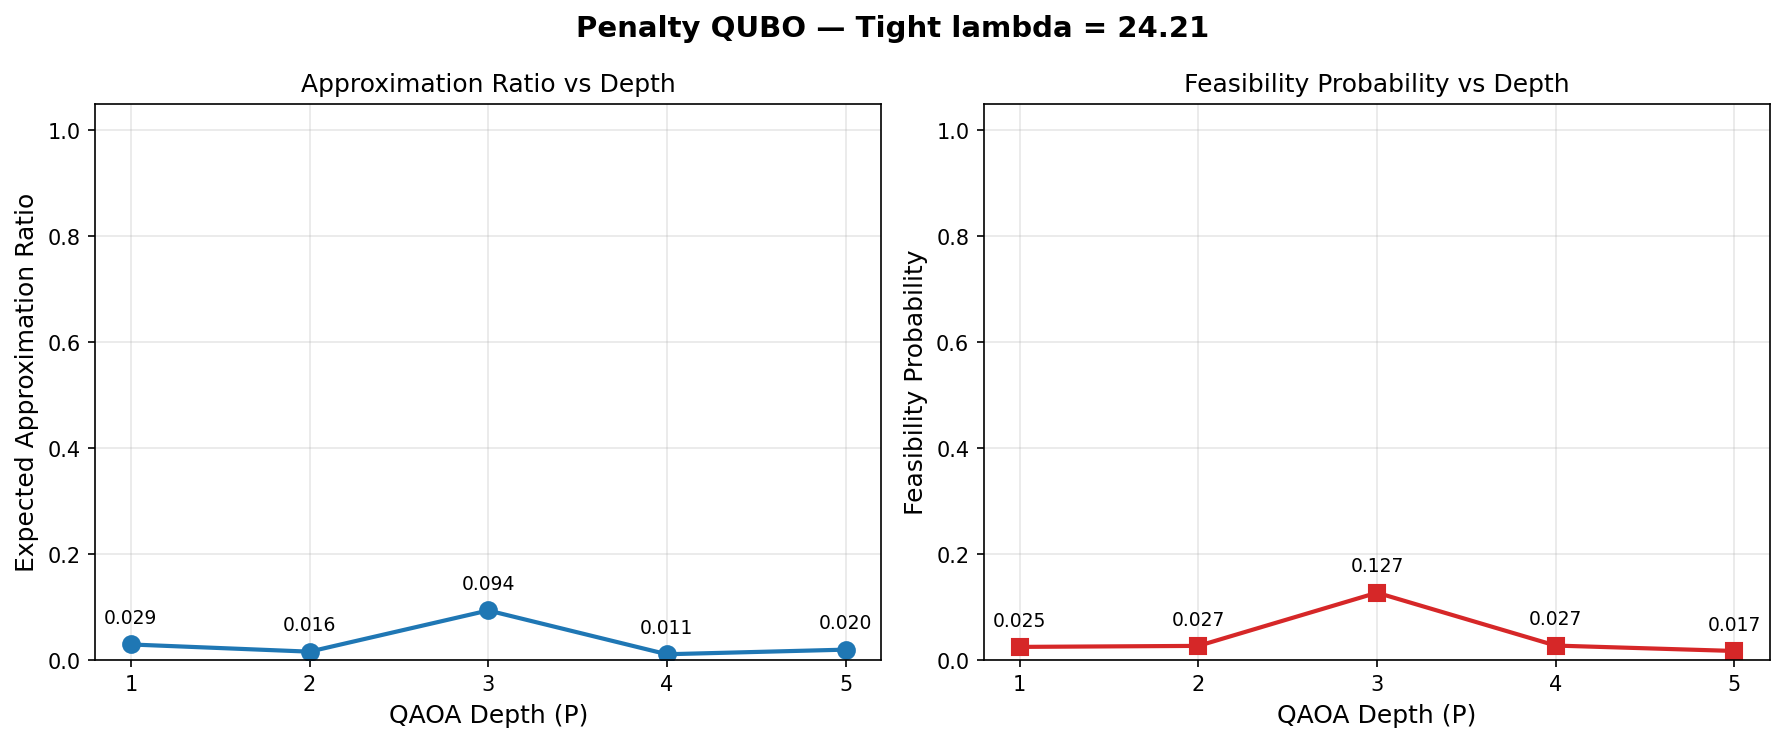

In [13]:
plot_depth_sweep(depths, ar_tight, feas_tight,
                 title=f"Penalty QUBO \u2014 Tight lambda = {lam_tight:.2f}",
                 save_path="tight_penalty_depth_sweep.png");

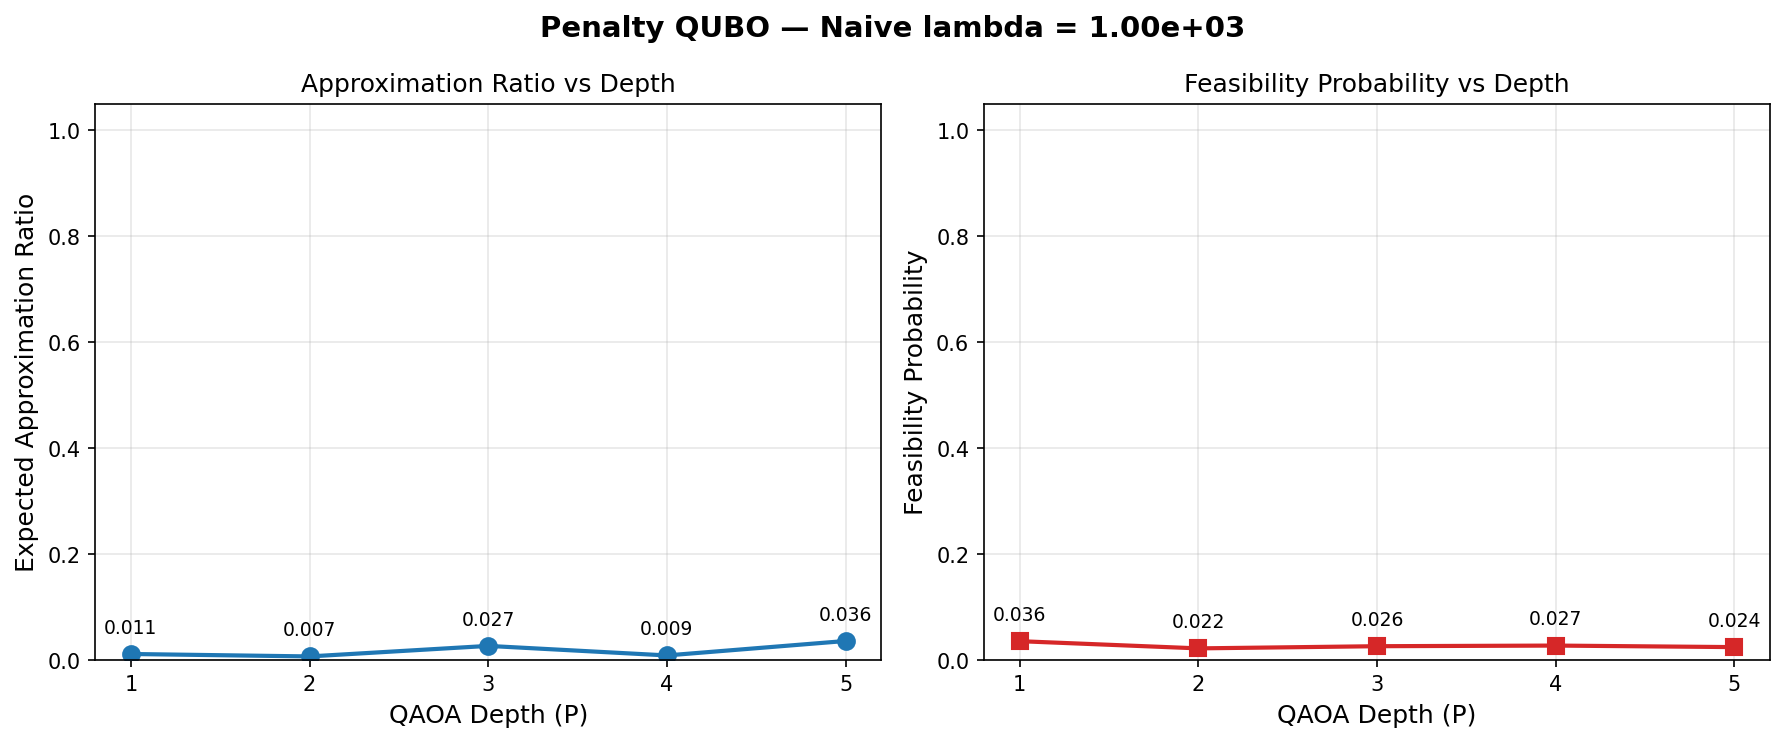

In [14]:
plot_depth_sweep(depths, ar_naive, feas_naive,
                 title=f"Penalty QUBO \u2014 Naive lambda = {lam_naive:.2e}",
                 save_path="naive_penalty_depth_sweep.png");

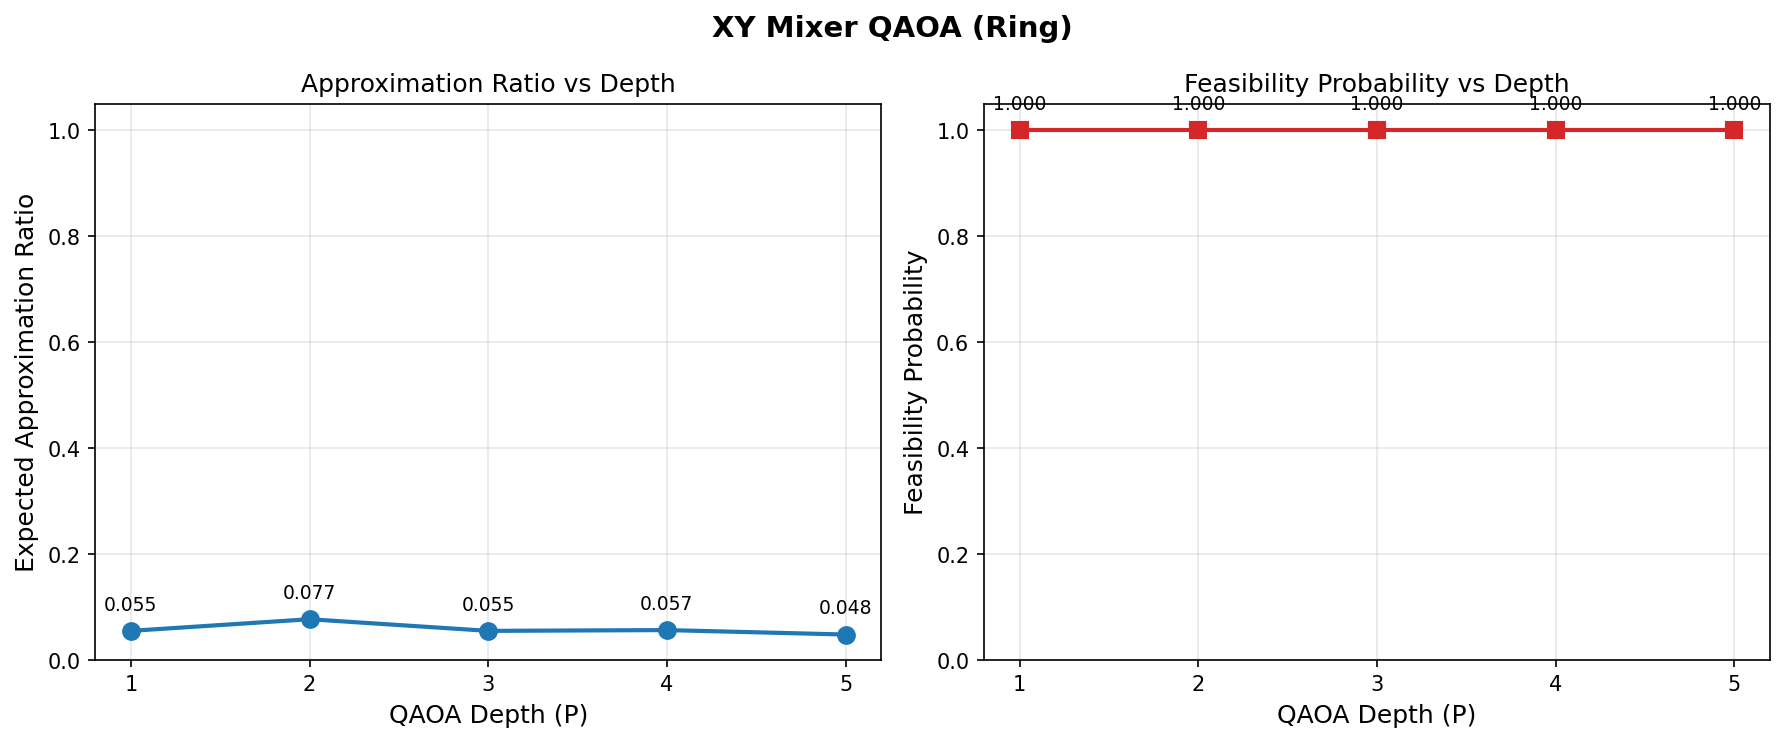

In [15]:
plot_depth_sweep(depths, ar_xy, feas_xy,
                 title="XY Mixer QAOA (Ring)",
                 save_path="xy_mixer_depth_sweep.png");

In [11]:
print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)
print(f"Optimal value: {optimal_value:.6f}")
print(f"Tight penalty lambda: {lam_tight:.4f}")
print()
header = f"{'P':<4} | {'Tight Penalty':^20} | {f'Naive Penalty {lam_naive:.2e}':^20} | {'XY Mixer (Ring)':^20}"
sub = f"{'':4} | {'E[AR]':>9} {'Feas':>9} | {'E[AR]':>9} {'Feas':>9} | {'E[AR]':>9} {'Feas':>9}"
print(header)
print(sub)
print("-" * 75)
for i, p in enumerate(depths):
    print(f"{p:<4} | {ar_tight[i]:>9.4f} {feas_tight[i]:>9.4f} | "
          f"{ar_naive[i]:>9.4f} {feas_naive[i]:>9.4f} | "
          f"{ar_xy[i]:>9.4f} {feas_xy[i]:>9.4f}")


SUMMARY
Optimal value: 0.474948
Tight penalty lambda: 24.2087

P    |    Tight Penalty     | Naive Penalty 1.00e+03 |   XY Mixer (Ring)   
     |     E[AR]      Feas |     E[AR]      Feas |     E[AR]      Feas
---------------------------------------------------------------------------
1    |    0.0295    0.0249 |    0.0115    0.0357 |    0.0552    1.0000
2    |    0.0159    0.0268 |    0.0069    0.0221 |    0.0771    1.0000
3    |    0.0937    0.1272 |    0.0268    0.0262 |    0.0552    1.0000
4    |    0.0110    0.0274 |    0.0088    0.0274 |    0.0567    1.0000
5    |    0.0197    0.0172 |    0.0360    0.0245 |    0.0483    1.0000


## Resource Estimation

RESOURCE ESTIMATION (Circuit Depth)

Resource Estimation for Tight Penalty
P      | Circuit Depth  | 2-Qubit Depth 
----------------------------------------
1      | 77             | 50            
2      | 120            | 78            
3      | 163            | 106           
4      | 206            | 134           
5      | 249            | 162           

Resource Estimation for Naive Penalty
P      | Circuit Depth  | 2-Qubit Depth 
----------------------------------------
1      | 77             | 50            
2      | 120            | 78            
3      | 163            | 106           
4      | 206            | 134           
5      | 249            | 162           

Resource Estimation for XY Mixer
P      | Circuit Depth  | 2-Qubit Depth 
----------------------------------------
1      | 32867          | 16436         
2      | 32996          | 16504         
3      | 33125          | 16572         
4      | 33254          | 16640         
5      | 33383          | 16708 

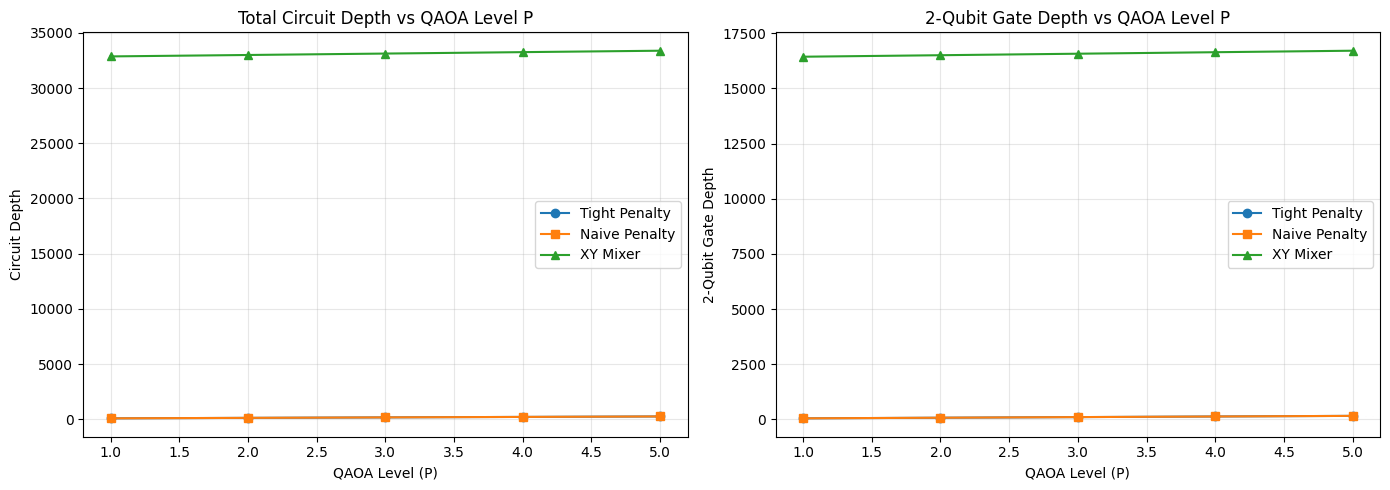

In [12]:
print("=" * 60)
print("RESOURCE ESTIMATION (Circuit Depth)")
print("=" * 60)

res_tight = estimate_resources(qubo_tight, depths, "Tight Penalty")
res_naive = estimate_resources(qubo_naive, depths, "Naive Penalty")
res_xy = estimate_resources(bqo, depths, "XY Mixer",
                            initial_state=init_qc, mixer=ring_xy_mixer)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(depths, res_tight[0], 'o-', label='Tight Penalty')
ax1.plot(depths, res_naive[0], 's-', label='Naive Penalty')
ax1.plot(depths, res_xy[0], '^-', label='XY Mixer')
ax1.set_xlabel('QAOA Level (P)')
ax1.set_ylabel('Circuit Depth')
ax1.set_title('Total Circuit Depth vs QAOA Level P')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(depths, res_tight[1], 'o-', label='Tight Penalty')
ax2.plot(depths, res_naive[1], 's-', label='Naive Penalty')
ax2.plot(depths, res_xy[1], '^-', label='XY Mixer')
ax2.set_xlabel('QAOA Level (P)')
ax2.set_ylabel('2-Qubit Gate Depth')
ax2.set_title('2-Qubit Gate Depth vs QAOA Level P')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('resource_estimation.png')
plt.show()